In [1]:
import pandas as pd
from xgboost import DMatrix
from src.helper import get_split_data

In [2]:
X_trn, y_trn, X_val, y_val, X_tst, y_tst = get_split_data.split_data_for_training(7,'data/preprocessed/imputed_data.csv',17)

X = pd.concat([X_trn, X_val], ignore_index=True)
y = pd.concat([pd.Series(y_trn), pd.Series(y_val)], ignore_index=True)

In [3]:
X = X.assign(result_match=y)
X.head()

,points_home,points_away,home_team_last_goal,home_team_last_shoton,home_team_last_possession,away_team_last_goal,away_team_last_shoton,away_team_last_possession,avg_team_strength_home,avg_team_strength_away,...,season_late,season_mid,dow_Friday,dow_Monday,dow_Saturday,dow_Sunday,dow_Thursday,dow_Tuesday,dow_Wednesday,result_match
0,4.0,0.0,1.0,5.0,47.0,1.0,7.0,52.0,63.318182,71.681818,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,3.0,0.0,3.0,5.0,53.0,1.0,2.0,66.0,71.318182,57.818182,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,3.0,3.0,1.0,7.0,47.0,3.0,1.0,47.0,63.924242,70.363636,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
3,3.0,4.0,1.0,12.0,34.0,1.0,1.0,55.0,78.318182,67.545455,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
4,6.0,0.0,1.0,6.0,35.0,1.0,2.0,53.0,80.189394,70.212121,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

loaded_model = XGBClassifier()
loaded_model.load_model("../hyperparameters/best_xgb_model.json")

y_pred = loaded_model.predict(X_tst)

print(y_pred)
f1 = f1_score(y_tst, y_pred)
f1

[0 1 0 0 0 0 0 1 1 1]


0.8571428571428571

In [5]:
import shap

shap.initjs()
shap_ex = shap.TreeExplainer(loaded_model)
vals = shap_ex(X_tst)

shap_df = pd.DataFrame(vals.values, columns=X_tst.columns)
# print(shap_df)

In [6]:
import numpy as np

print(pd.concat([shap_df.sum(axis='columns').rename('pred') + vals.base_values,
                 pd.Series(y_pred, name='predicted values'),
                 pd.Series(y_tst, name='true values')], axis='columns')
      .assign(prob=lambda adf: (np.exp(adf.pred) / (1 + np.exp(adf.pred))))
      )

       pred  predicted values  true values      prob
0 -0.526982                 0            0  0.371221
1  0.160567                 1            1  0.540056
2 -0.126010                 0            0  0.468539
3 -0.474813                 0            0  0.383478
4 -0.126010                 0            0  0.468539
5 -0.420469                 0            0  0.396405
6 -0.088115                 0            0  0.477985
7  0.430340                 1            1  0.605955
8  0.044764                 1            0  0.511189
9  0.218950                 1            1  0.554520


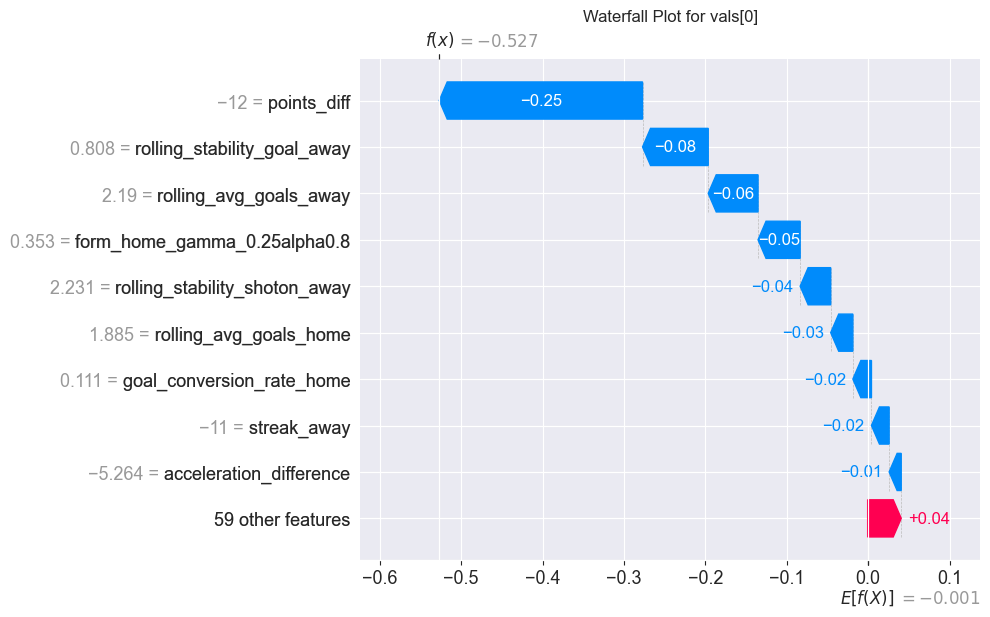

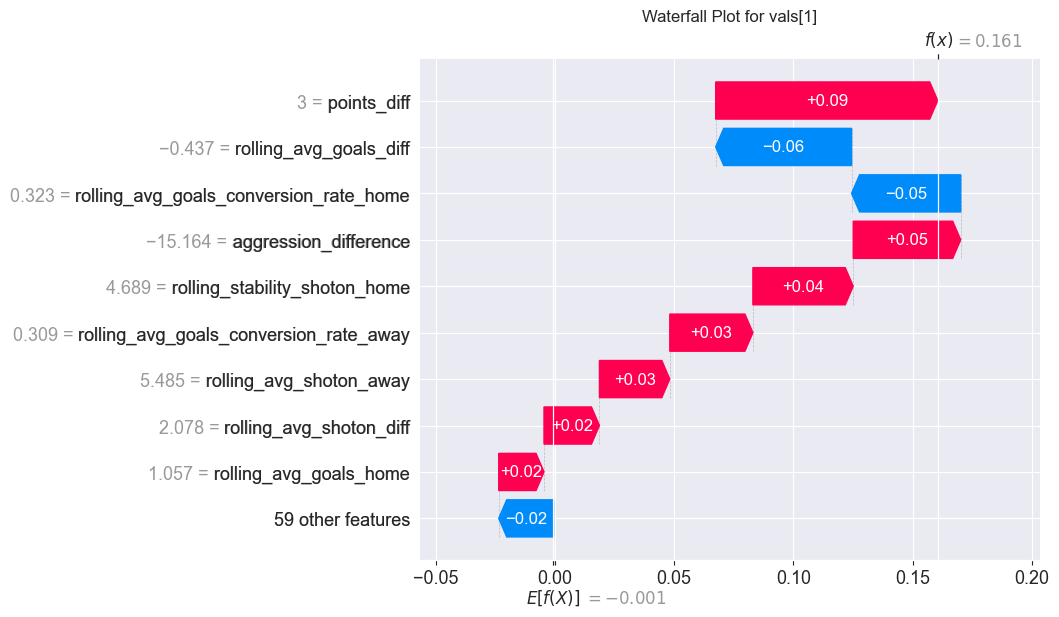

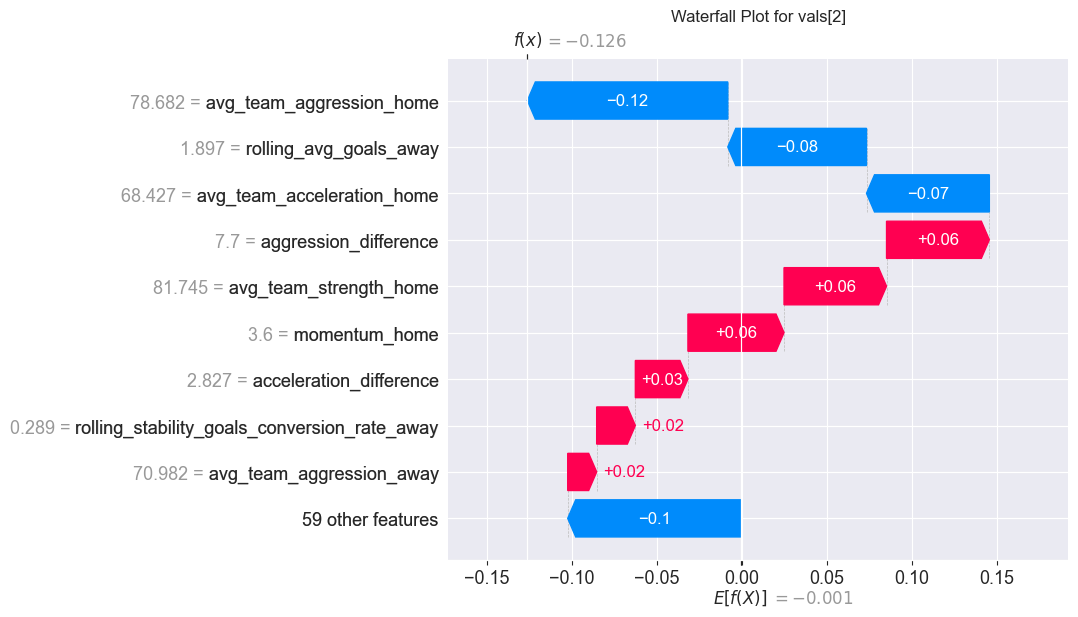

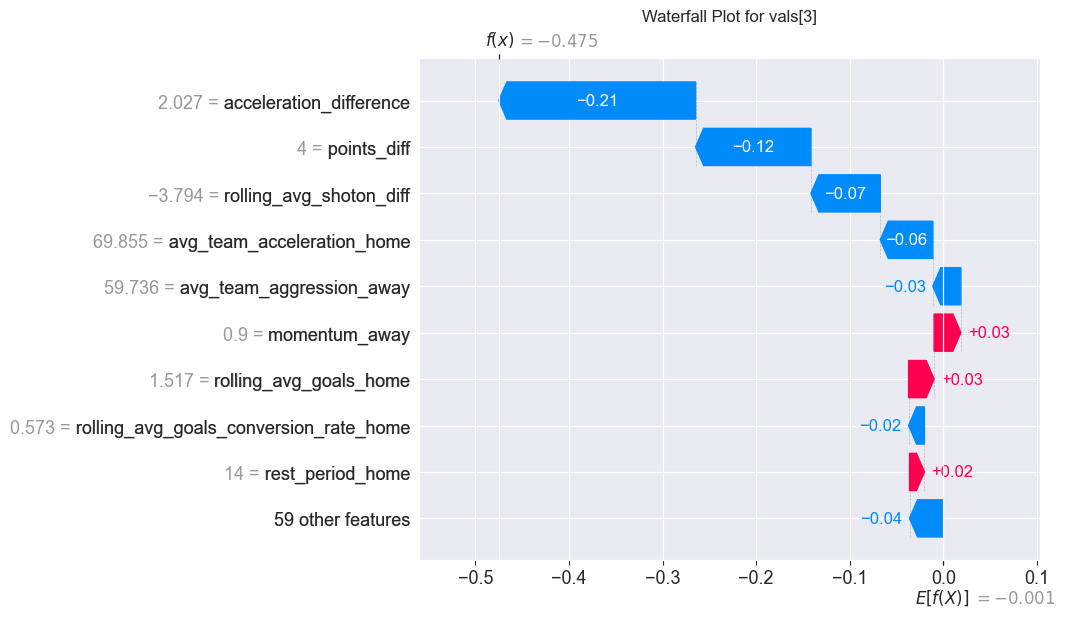

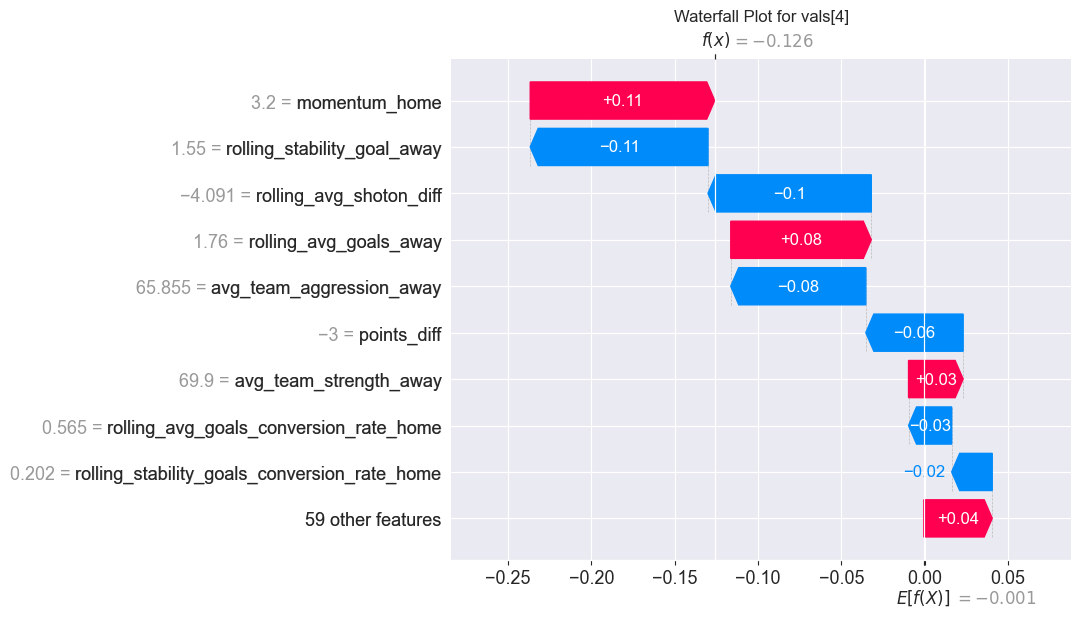

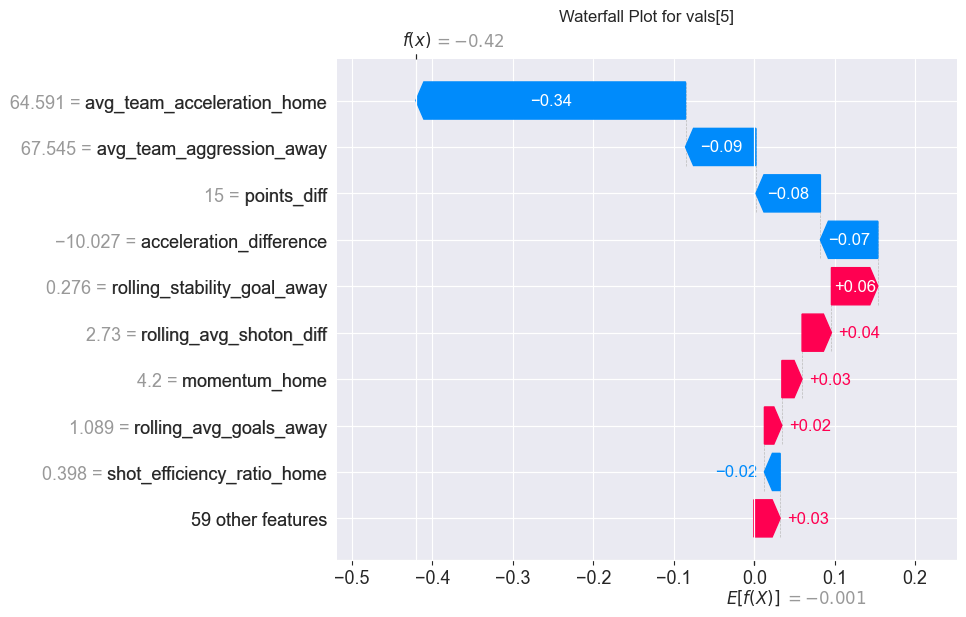

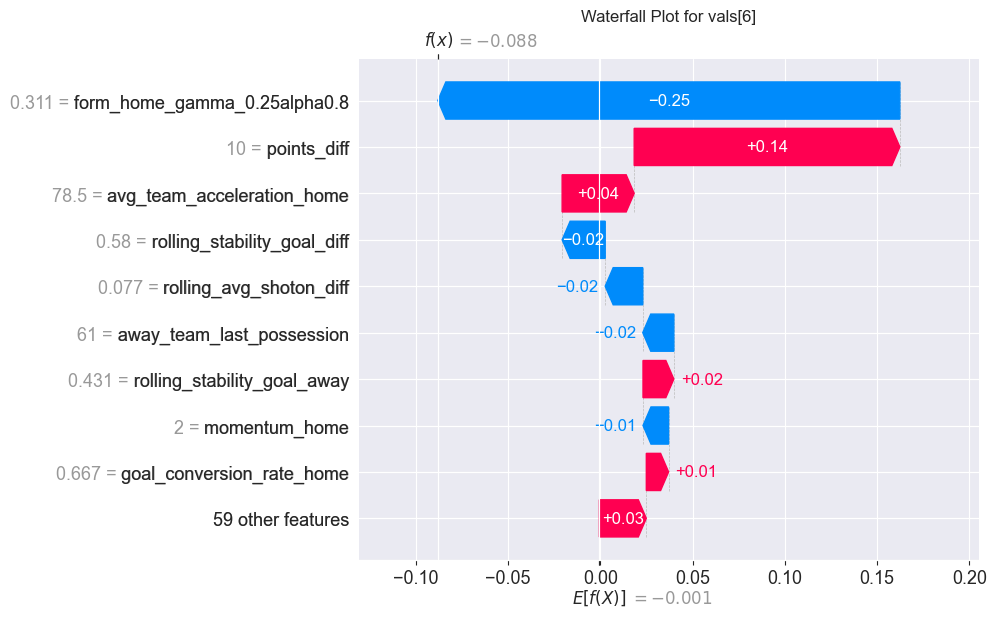

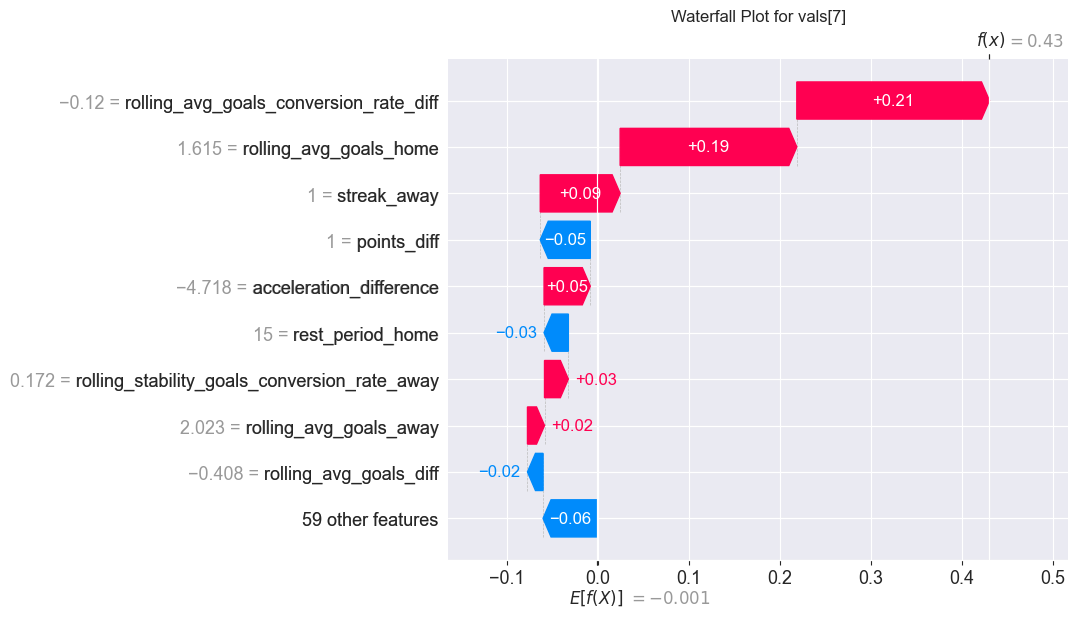

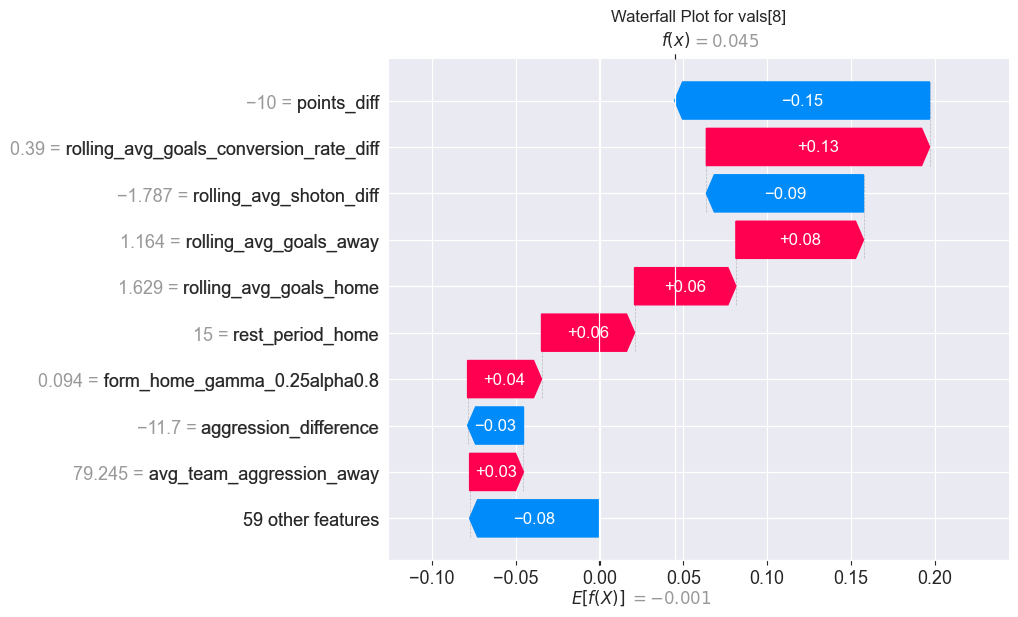

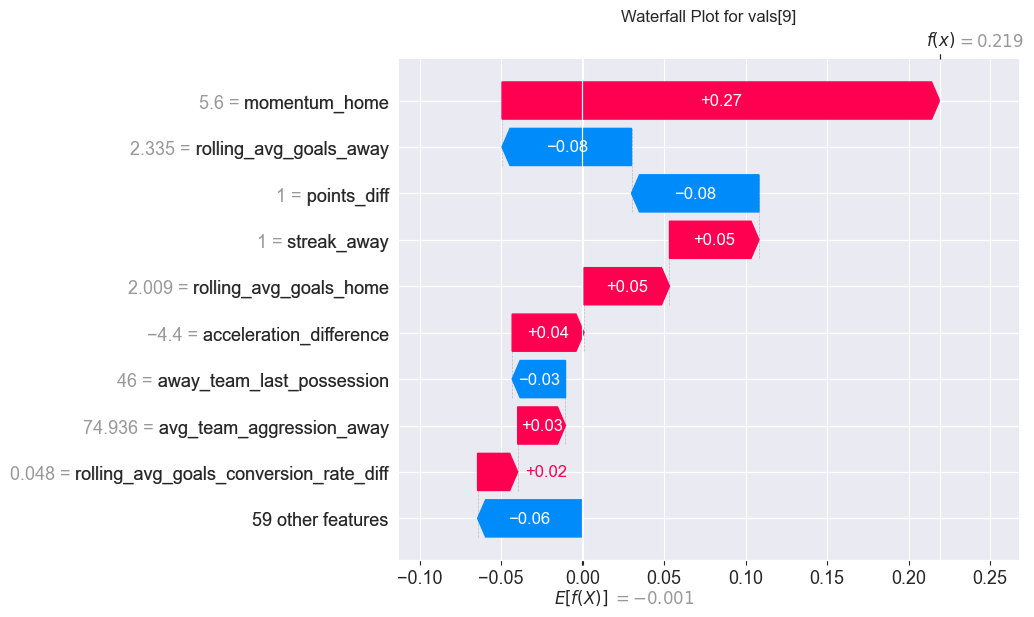

In [7]:
from matplotlib import pyplot as plt

for i, val in enumerate(vals):
    fig = plt.figure(figsize=(8, 4))
    shap.plots.waterfall(val, show=False)
    plt.title(f"Waterfall Plot for vals[{i}]")
    plt.show()

In [ ]:
booster = loaded_model.get_booster()

shap_preds = booster.predict(DMatrix(X_tst), pred_contribs=True)
shap_interactions = booster.predict(DMatrix(X_tst), pred_interactions=True)

In [28]:
def generate_prediction_explanation(index, X, feature_names, shapley_values, predictions):
    explanation = {}
    explanation["prediction"] = predictions[index]
    for feature, original_value, shap_value in zip(feature_names, X[index], shapley_values[index, :]):
        explanation[feature] = {
            "original_value": original_value,
            "shap_value": shap_value
        }
    return explanation


index_to_explain = 8
explanation_json = generate_prediction_explanation(
    index_to_explain,
    X_tst.columns,
    X_tst,
    shap_preds,
    y_pred
)
print(explanation_json)

{'prediction': 1, 'points_home': {'original_value': 'a', 'shap_value': -0.0041155056}, 'points_away': {'original_value': 'v', 'shap_value': -0.09234183}, 'home_team_last_goal': {'original_value': 'g', 'shap_value': 0.01646023}, 'home_team_last_shoton': {'original_value': '_', 'shap_value': 0.032528363}, 'home_team_last_possession': {'original_value': 't', 'shap_value': -0.035474133}, 'away_team_last_goal': {'original_value': 'e', 'shap_value': -0.02036462}, 'away_team_last_shoton': {'original_value': 'a', 'shap_value': -0.020582337}, 'away_team_last_possession': {'original_value': 'm', 'shap_value': 0.051918857}, 'avg_team_strength_home': {'original_value': '_', 'shap_value': 0.017083008}, 'avg_team_strength_away': {'original_value': 's', 'shap_value': 0.043885075}, 'strength_difference': {'original_value': 't', 'shap_value': -0.08484715}, 'avg_team_aggression_home': {'original_value': 'r', 'shap_value': 0.059613187}, 'avg_team_aggression_away': {'original_value': 'e', 'shap_value': 0.

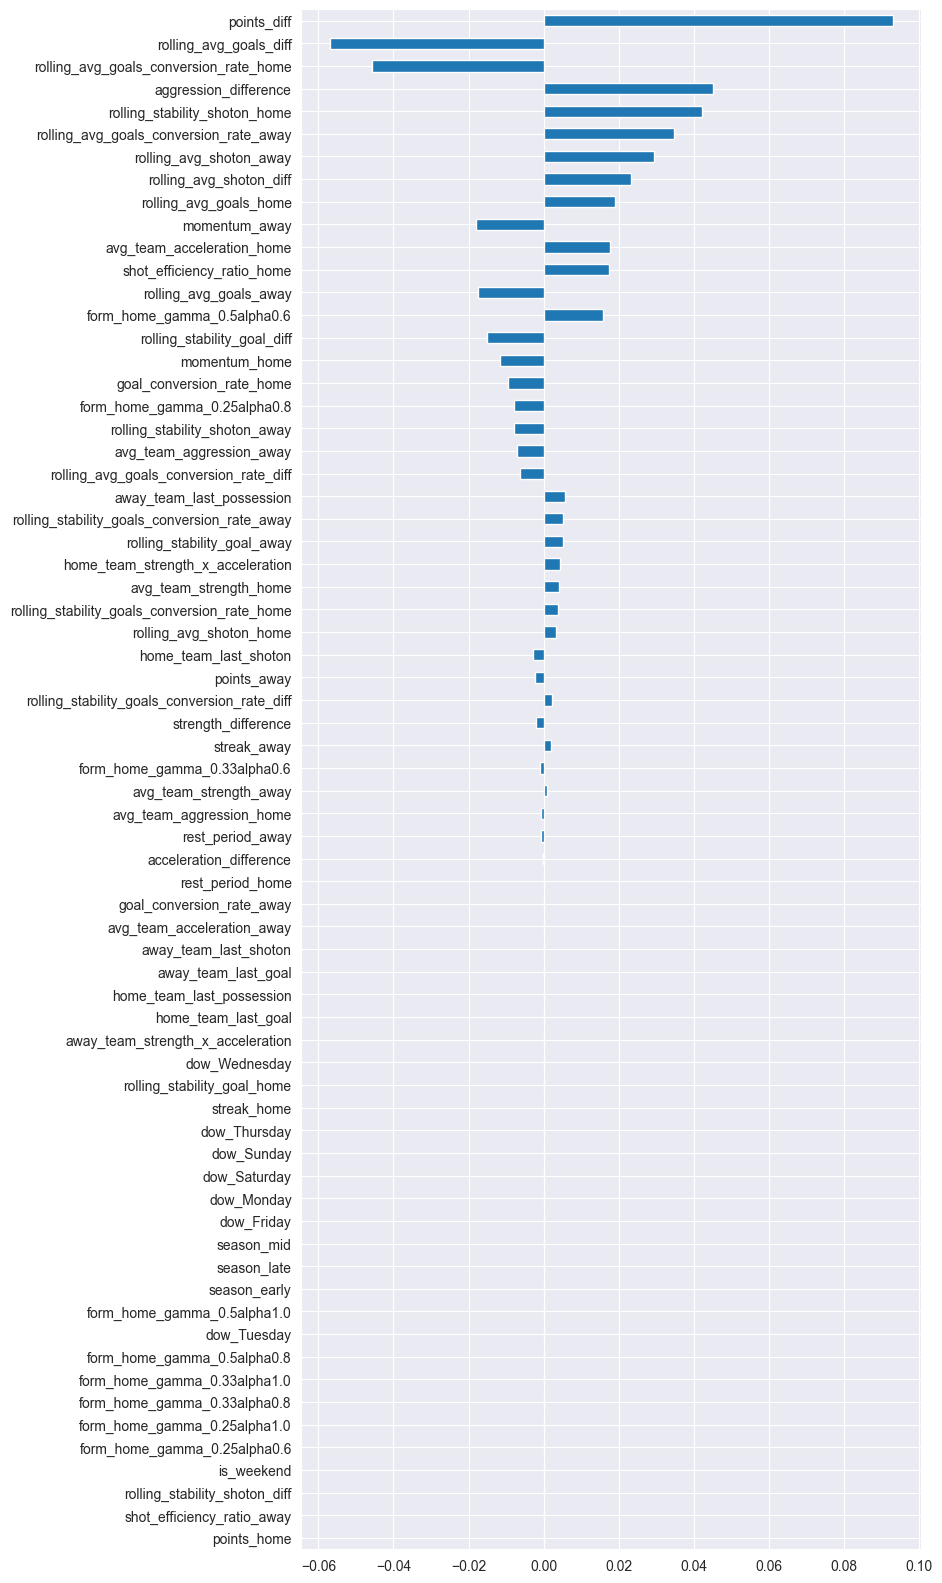

In [8]:
fig, ax = plt.subplots(figsize=(8, 20))
(pd.Series(vals.values[1], index=X_tst.columns)
 .sort_values(key=np.abs)
 .plot.barh(ax=ax)
 )
plt.show()

In [9]:
# X_tst.columns

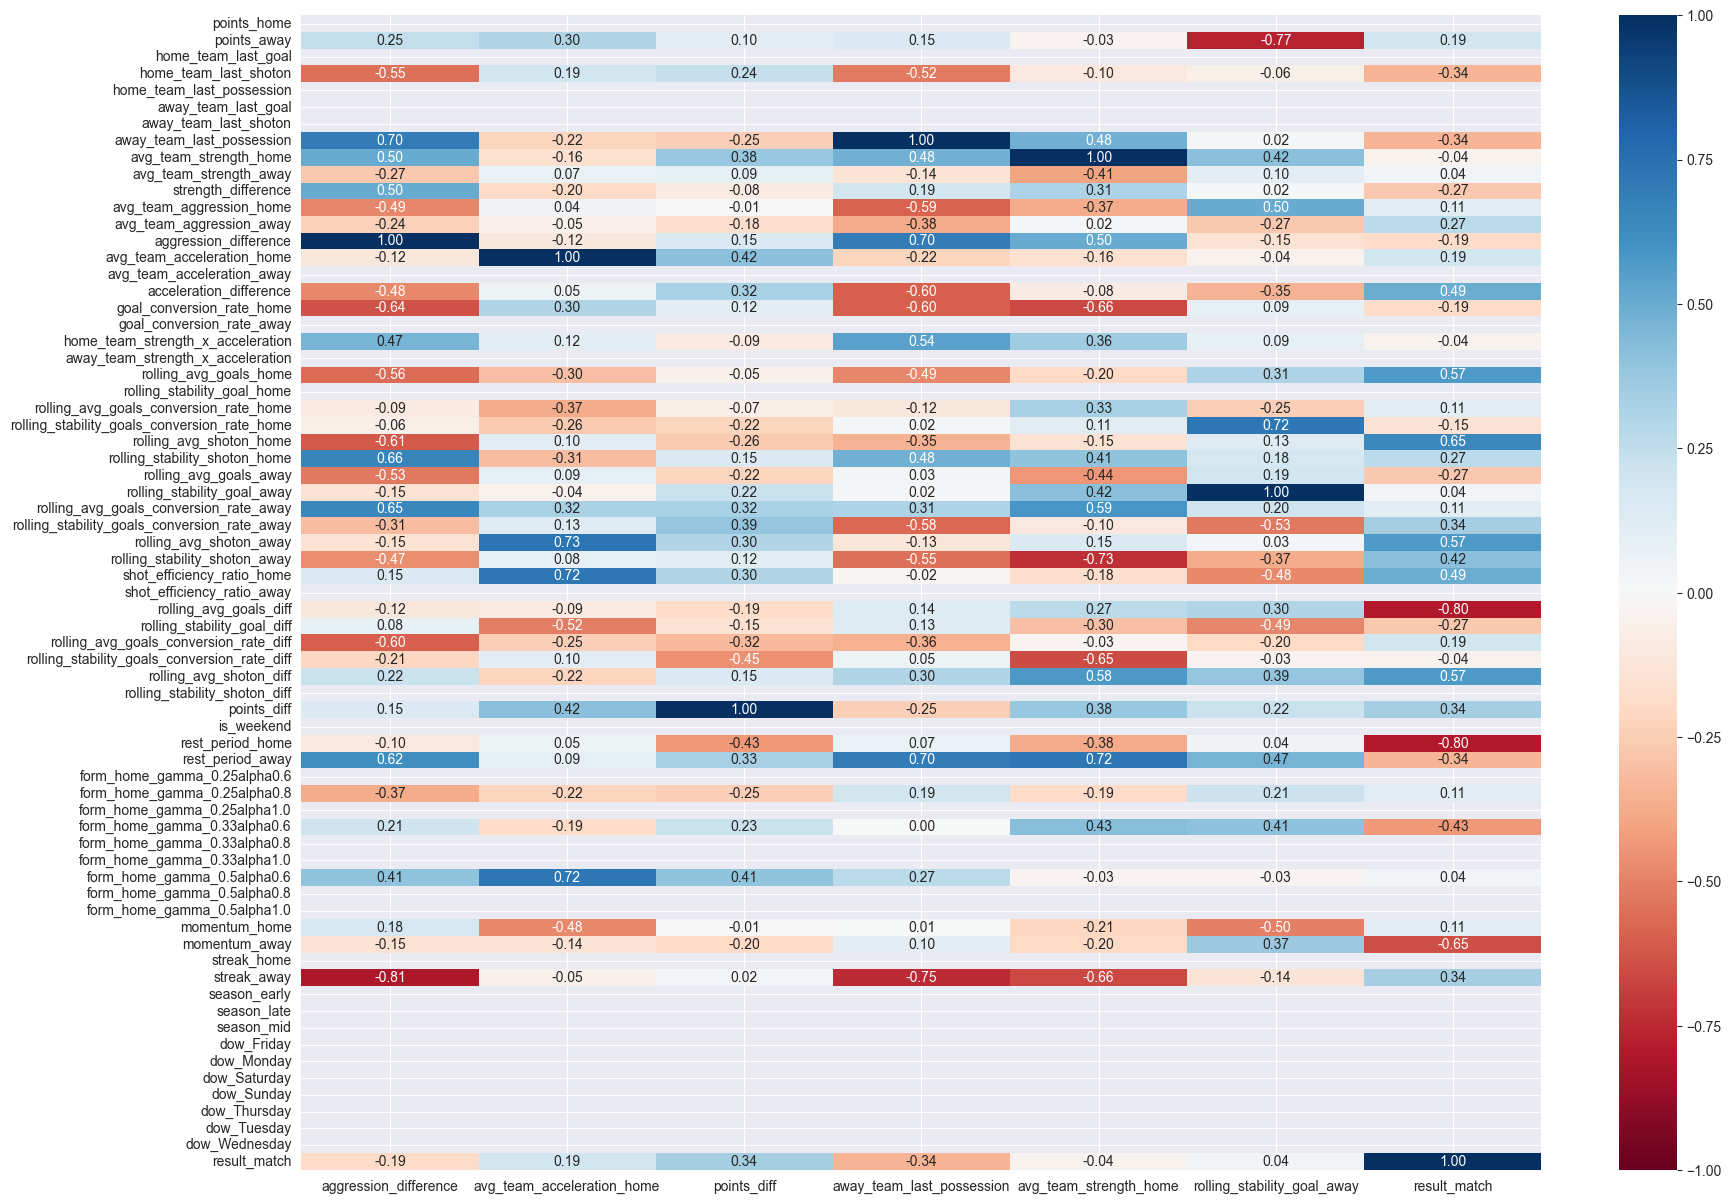

In [10]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(20, 15))
sns.heatmap(shap_df
            .assign(result_match=y_tst)
            .corr(method='spearman')
            .loc[:,
            ['aggression_difference', 'avg_team_acceleration_home', 'points_diff',
             'away_team_last_possession', 'avg_team_strength_home', 'rolling_stability_goal_away',
             'result_match']],
            cmap='RdBu', annot=True, fmt='.2f', vmin=-1, vmax=1, ax=ax
            )
plt.show()

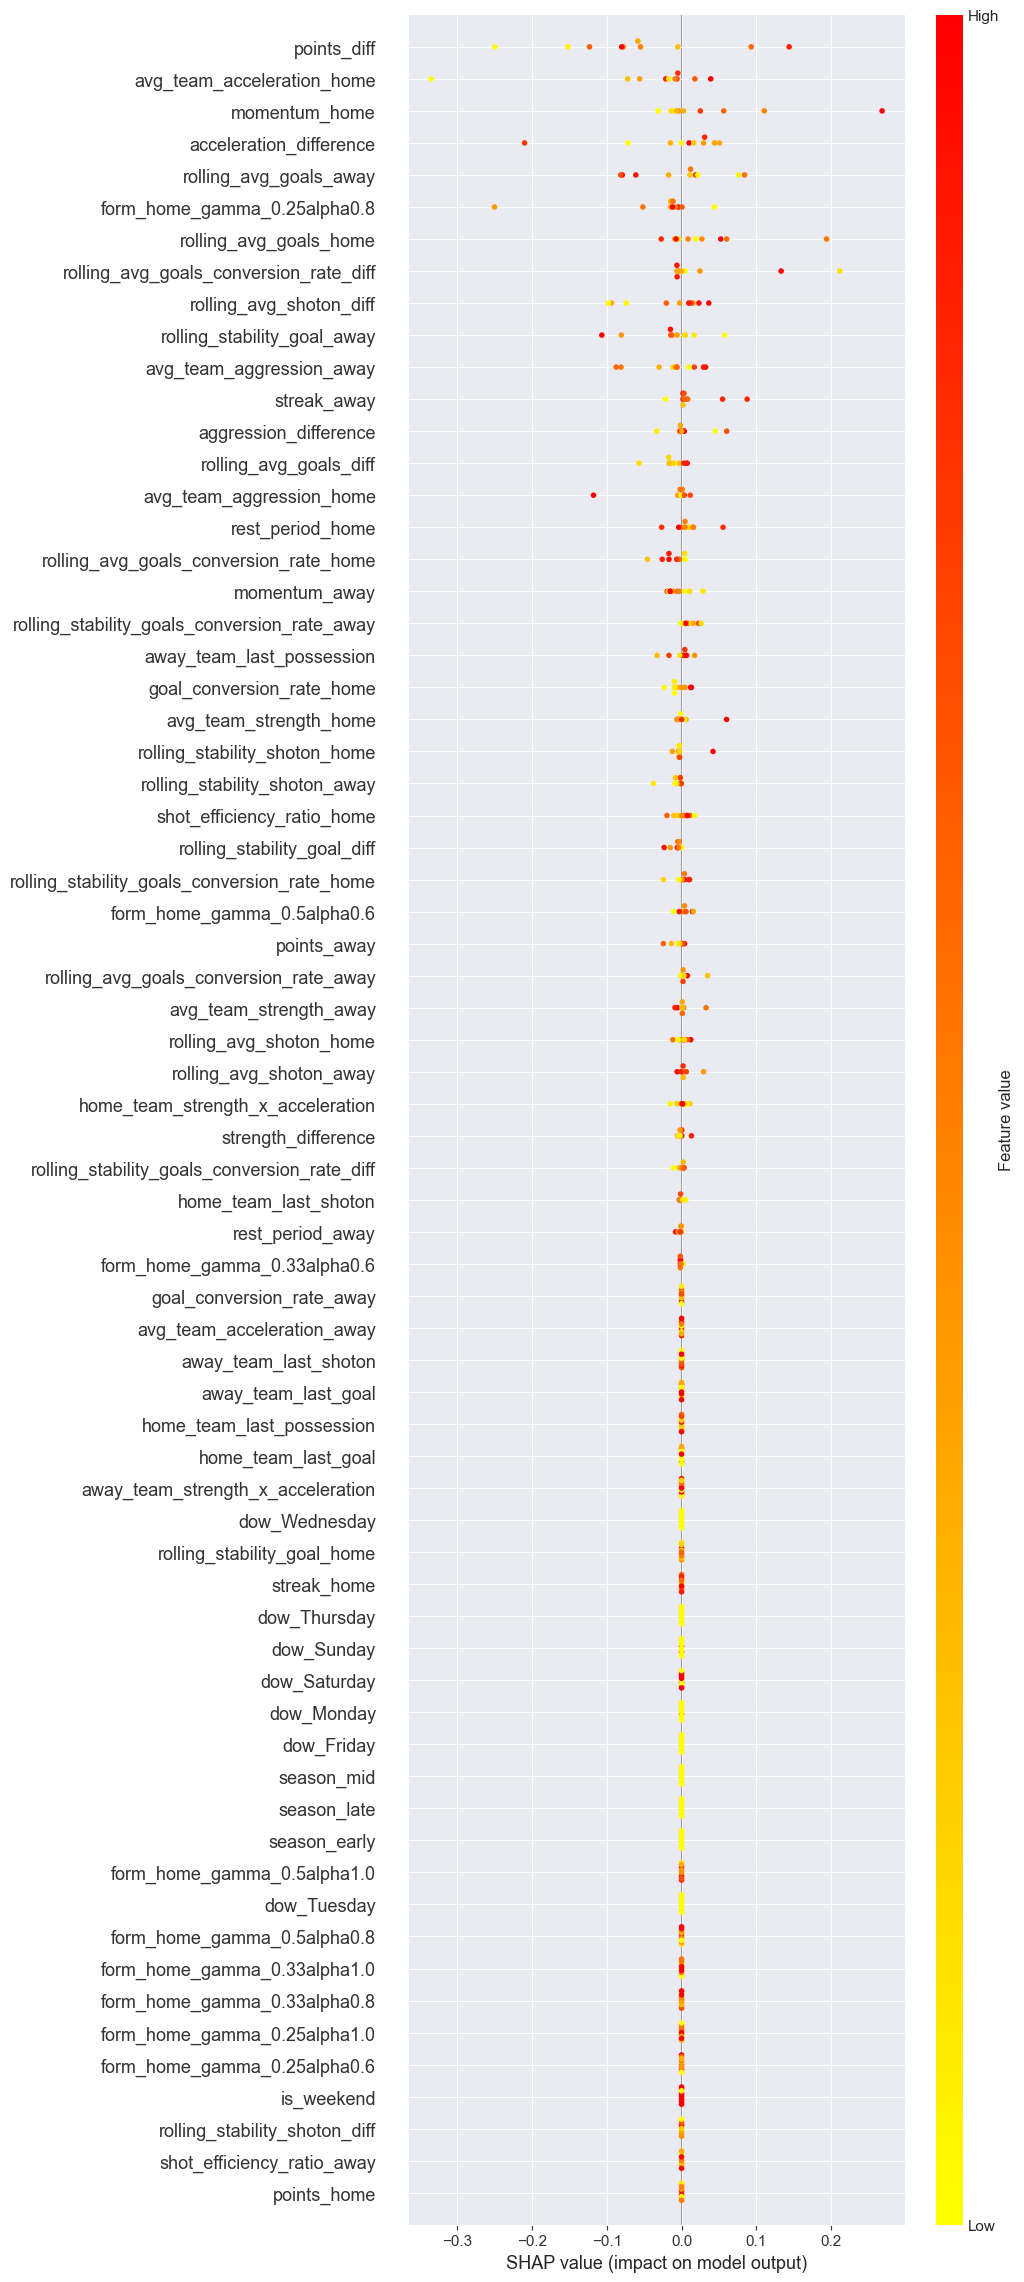

In [11]:
from matplotlib import cm

fig = plt.figure(figsize=(8, 4))
shap.plots.beeswarm(vals, max_display=len(X_tst.columns), color=cm.autumn_r)

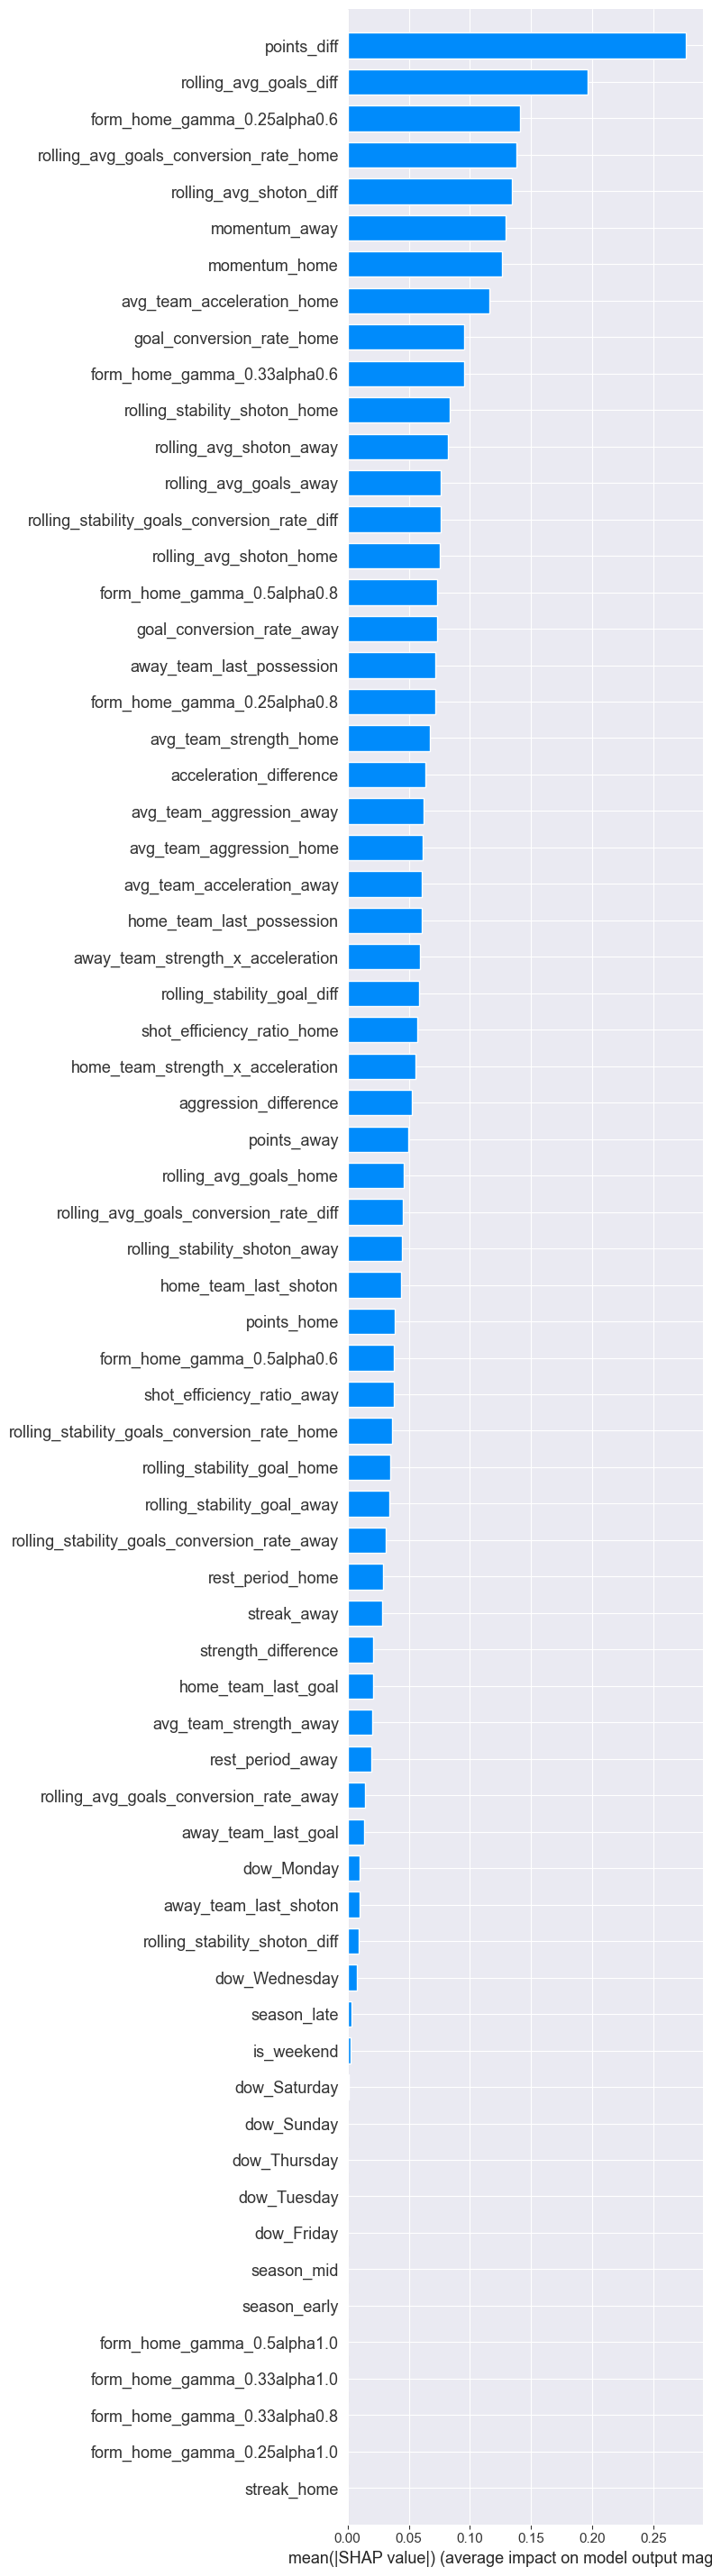

In [13]:
shap.summary_plot(shap_preds[:, :-1], features=X_tst, plot_type="bar", max_display=len(X_tst.columns))

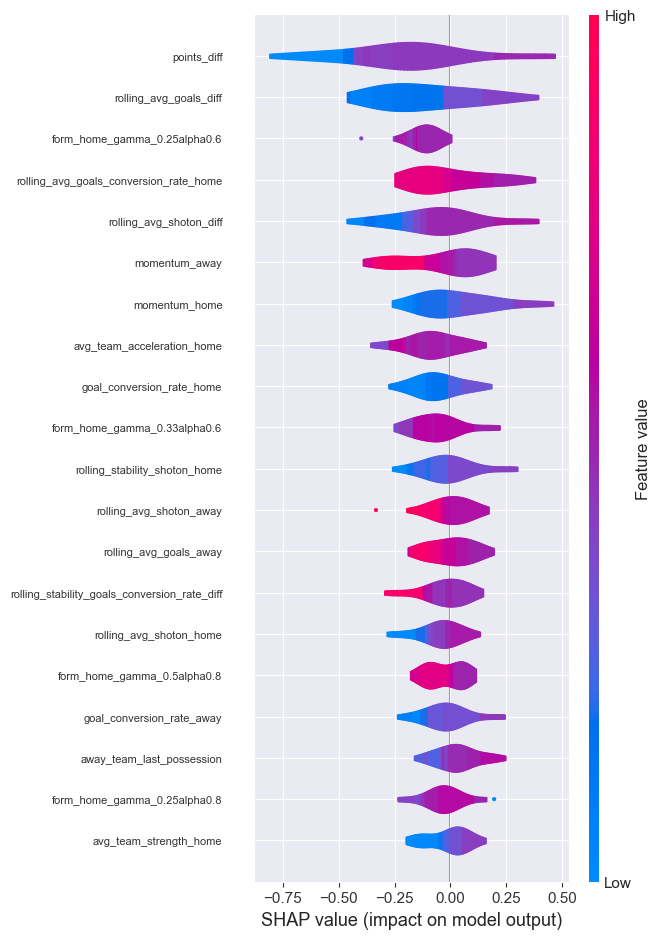

In [14]:
shap.summary_plot(shap_preds[:, :-1], X_tst, plot_type="violin", show=False)
plt.yticks(fontsize=8)
plt.show()

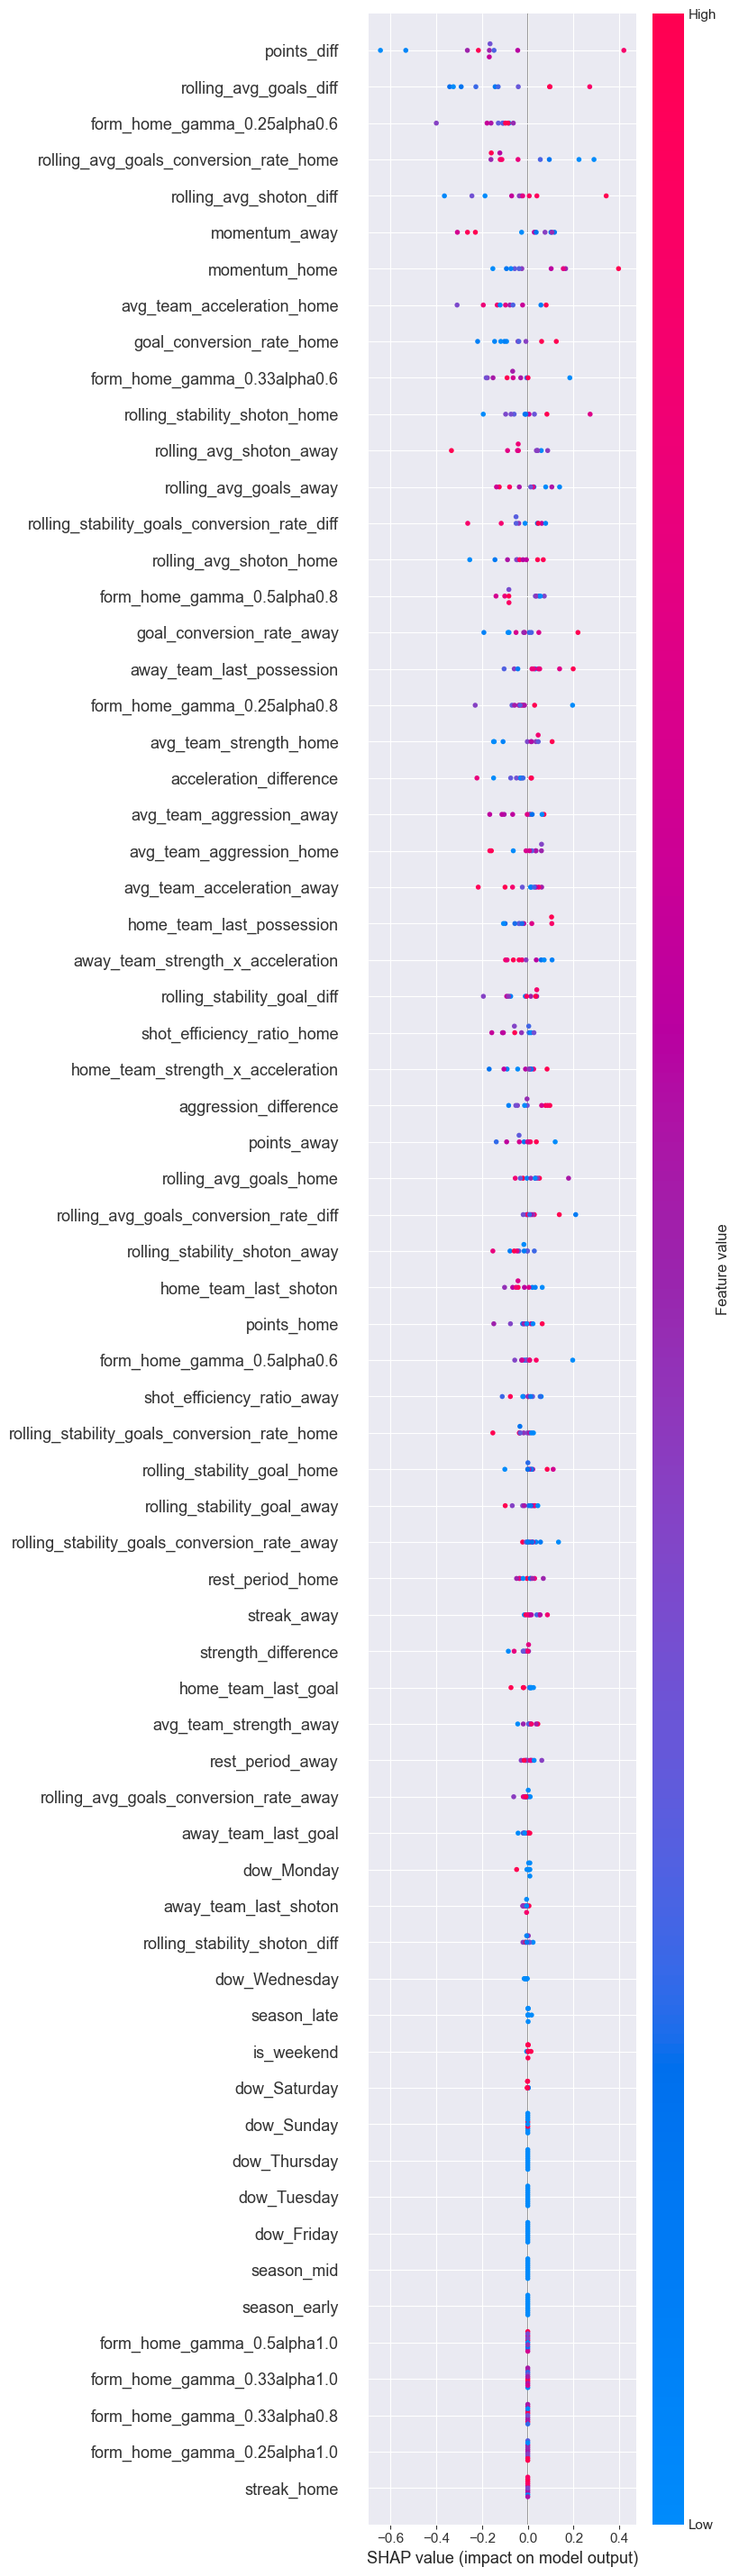

In [15]:
shap.summary_plot(shap_preds[:, :-1], features=X_tst, max_display=len(X_tst.columns))

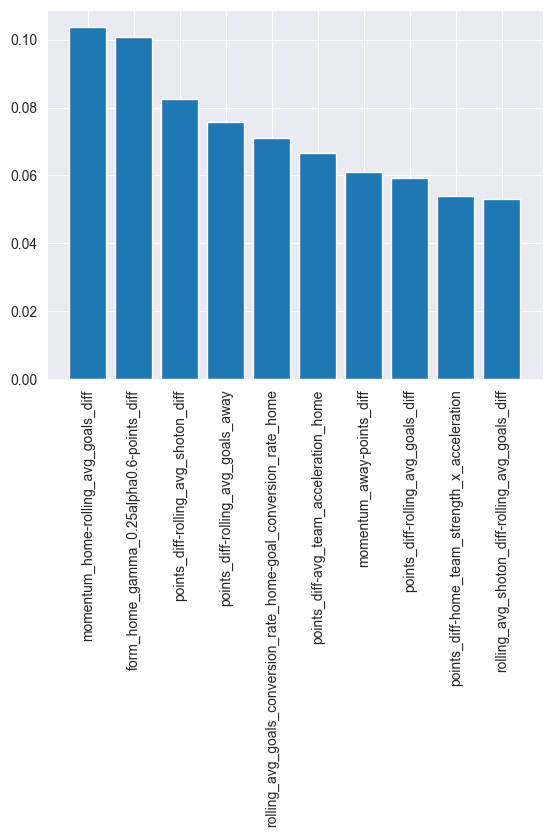

In [16]:
def plot_top_k_interactions(feature_names, shap_interactions, k):
    # Get the mean absolute contribution for each feature interaction
    aggregate_interactions = np.mean(np.abs(shap_interactions[:, :-1, :-1]), axis=0)
    interactions = []

    for i in range(aggregate_interactions.shape[0]):
        for j in range(aggregate_interactions.shape[1]):
            if j < i:
                interactions.append(
                    (feature_names[i] + "-" + feature_names[j], aggregate_interactions[i][j] * 2)
                )

    interactions.sort(key=lambda x: x[1], reverse=True)
    interaction_features, interaction_values = map(tuple, zip(*interactions))

    plt.bar(interaction_features[:k], interaction_values[:k])
    plt.xticks(rotation=90)
    plt.show()

    return interactions


top_interactions = plot_top_k_interactions(X_tst.columns, shap_interactions, 10)

In [17]:
top_interactions[:5]

[('momentum_home-rolling_avg_goals_diff', 0.10362298786640167),
 ('form_home_gamma_0.25alpha0.6-points_diff', 0.10083682835102081),
 ('points_diff-rolling_avg_shoton_diff', 0.08236391842365265),
 ('points_diff-rolling_avg_goals_away', 0.07584801316261292),
 ('rolling_avg_goals_conversion_rate_home-goal_conversion_rate_home',
  0.07095994055271149)]

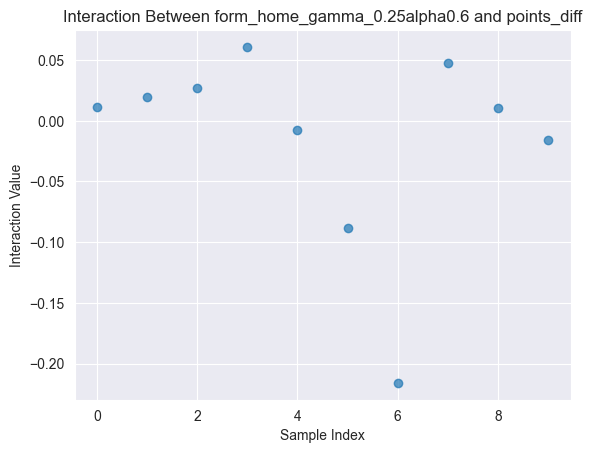

In [22]:
from src.helper import plot_feature_interactions

plot_feature_interactions.plot_feature_interaction(feature_names=list(X_tst.columns),
                                                   shap_interactions=shap_interactions, feature1='form_home_gamma_0.25alpha0.6',
                                                   feature2='points_diff')

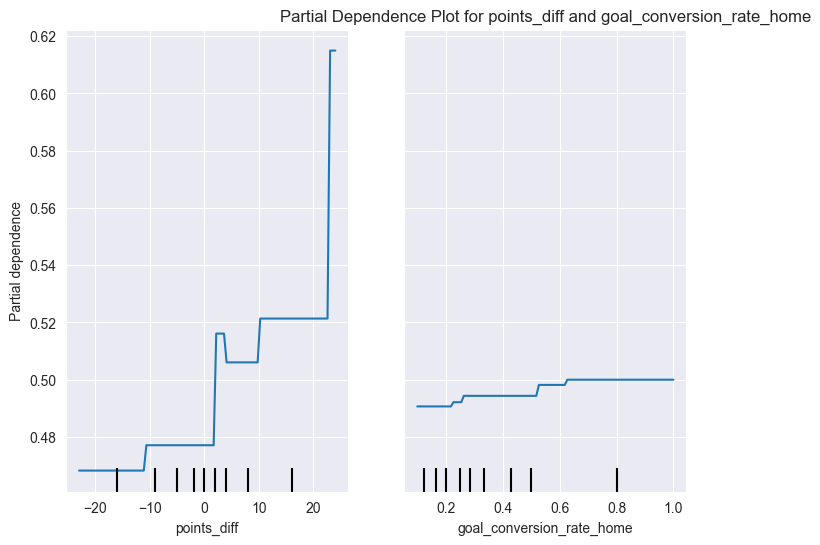

In [24]:
plot_feature_interactions.plot_pdp(loaded_model, X_trn, ['points_diff', 'goal_conversion_rate_home'])

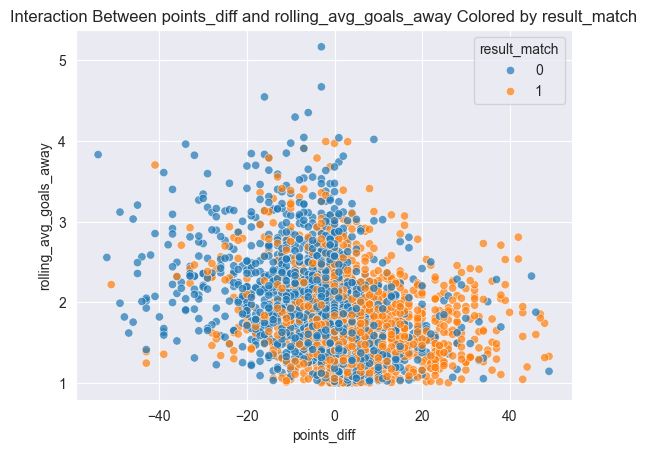

In [26]:
plot_feature_interactions.plot_scatter_interaction(X, 'points_diff', 'rolling_avg_goals_away', 'result_match')

In [27]:
def generate_prediction_explanation(index, X, feature_names, shapley_values, predictions):
    explanation = {}
    explanation["prediction"] = predictions[index]
    for feature, original_value, shap_value in zip(feature_names, X[index], shapley_values[index, :]):
        explanation[feature] = {
            "original_value": original_value,
            "shap_value": shap_value
        }
    return explanation


index_to_explain = 5
explanation_json = generate_prediction_explanation(
    index_to_explain,
    X_tst.columns,
    X_tst,
    shap_preds,
    y_pred
)
print(explanation_json)

{'prediction': 0, 'points_home': {'original_value': 'a', 'shap_value': -0.0019663796}, 'points_away': {'original_value': 'w', 'shap_value': -0.13757785}, 'home_team_last_goal': {'original_value': 'a', 'shap_value': 0.009679529}, 'home_team_last_shoton': {'original_value': 'y', 'shap_value': -0.014763171}, 'home_team_last_possession': {'original_value': '_', 'shap_value': -0.098677814}, 'away_team_last_goal': {'original_value': 't', 'shap_value': -0.014098929}, 'away_team_last_shoton': {'original_value': 'e', 'shap_value': -0.0052017723}, 'away_team_last_possession': {'original_value': 'a', 'shap_value': -0.059162177}, 'avg_team_strength_home': {'original_value': 'm', 'shap_value': 0.045707628}, 'avg_team_strength_away': {'original_value': '_', 'shap_value': -0.019661602}, 'strength_difference': {'original_value': 'l', 'shap_value': -0.0071880147}, 'avg_team_aggression_home': {'original_value': 'a', 'shap_value': 0.036231227}, 'avg_team_aggression_away': {'original_value': 's', 'shap_va